# FinSight — 01 · Exploration des Données (EDA)

**Objectif :** Comprendre la structure, la qualité et les caractéristiques statistiques des données financières et macroéconomiques avant de passer au feature engineering.

**Actifs analysés :**
- Actions : `MC.PA` (LVMH), `TTE.PA` (TotalEnergies), `AAPL`, `MSFT`
- Métaux précieux : `GC=F` (Or), `SI=F` (Argent), `PL=F` (Platine)

**Plan :**
1. Configuration et imports
2. Collecte des données
3. Inspection qualité (valeurs manquantes, types, outliers)
4. Statistiques descriptives
5. Visualisations des prix et volumes
6. Analyse des rendements et de la volatilité
7. Corrélations inter-actifs
8. Données macroéconomiques (FRED)
9. Distribution de la variable cible
10. Conclusions et insights

## 1. Configuration et imports

In [1]:
import sys
sys.path.insert(0, '..')  # Pour importer les modules src/

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from dotenv import load_dotenv

from src.config import (
    ALL_TICKERS, TICKER_LABELS,
    TRAIN_START_DATE, TEST_END_DATE,
    TREND_UP_THRESHOLD, TREND_DOWN_THRESHOLD,
)
from src.data.collector import collect_all_tickers, collect_fred_data
from src.data.features import build_feature_matrix, get_feature_names

load_dotenv('../.env')

# Style global
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid', palette='tab10')

print('Imports OK')

Imports OK


## 2. Collecte des données

In [2]:
# Collecte de tous les actifs (2015 → fin 2024)
prices = collect_all_tickers(
    tickers=ALL_TICKERS,
    start_date=TRAIN_START_DATE,
    end_date=TEST_END_DATE,
    save_raw=True,
)

print(f"Actifs collectés : {list(prices.keys())}")

Actifs collectés : ['MC.PA', 'TTE.PA', 'AAPL', 'MSFT', 'GC=F', 'SI=F', 'PL=F']


In [3]:
# Collecte des données macro FRED
macro = collect_fred_data(start_date=TRAIN_START_DATE, end_date=TEST_END_DATE)

print(f"Données macro : {macro.shape}")
macro.head()

Données macro : (2642, 3)


,fed_rate,cpi,us_10y
Date,,,
2015-01-01,0.11,234.747,NaN
2015-01-02,0.11,234.747,2.12
2015-01-05,0.11,234.747,2.04
2015-01-06,0.11,234.747,1.97
2015-01-07,0.11,234.747,1.96


## 3. Inspection qualité

In [4]:
# Aperçu rapide de chaque actif
for ticker, df in prices.items():
    label = TICKER_LABELS[ticker]
    missing = df.isnull().sum().sum()
    print(f"[{ticker}] {label:20s} | Shape: {df.shape} | Manquants: {missing} | "
          f"Période: {df.index.min().date()} → {df.index.max().date()}")

[MC.PA] LVMH                 | Shape: (2560, 5) | Manquants: 0 | Période: 2015-01-02 → 2024-12-30
[TTE.PA] TotalEnergies        | Shape: (2560, 5) | Manquants: 0 | Période: 2015-01-02 → 2024-12-30
[AAPL] Apple                | Shape: (2515, 5) | Manquants: 0 | Période: 2015-01-02 → 2024-12-30
[MSFT] Microsoft            | Shape: (2515, 5) | Manquants: 0 | Période: 2015-01-02 → 2024-12-30
[GC=F] Or (Gold)            | Shape: (2512, 5) | Manquants: 0 | Période: 2015-01-02 → 2024-12-30
[SI=F] Argent (Silver)      | Shape: (2512, 5) | Manquants: 0 | Période: 2015-01-02 → 2024-12-30
[PL=F] Platine (Platinum)   | Shape: (2511, 5) | Manquants: 0 | Période: 2015-01-02 → 2024-12-30


In [5]:
# Inspection détaillée sur AAPL (exemple représentatif)
df_aapl = prices['AAPL']
print("Shape:", df_aapl.shape)
print("\nInfo:")
df_aapl.info()
print("\nPremières lignes:")
df_aapl.head()

Shape: (2515, 5)

Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2515 entries, 2015-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    2515 non-null   float64
 1   High    2515 non-null   float64
 2   Low     2515 non-null   float64
 3   Close   2515 non-null   float64
 4   Volume  2515 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.9 KB

Premières lignes:


Price,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,24.648440,24.659504,23.754466,24.192602,212818400
2015-01-05,23.962477,24.042138,23.325190,23.511065,257142000
2015-01-06,23.575230,23.772169,23.152583,23.513271,263188400
2015-01-07,23.721280,23.942561,23.610640,23.842985,160423600
2015-01-08,24.170475,24.816614,24.053195,24.759081,237458000


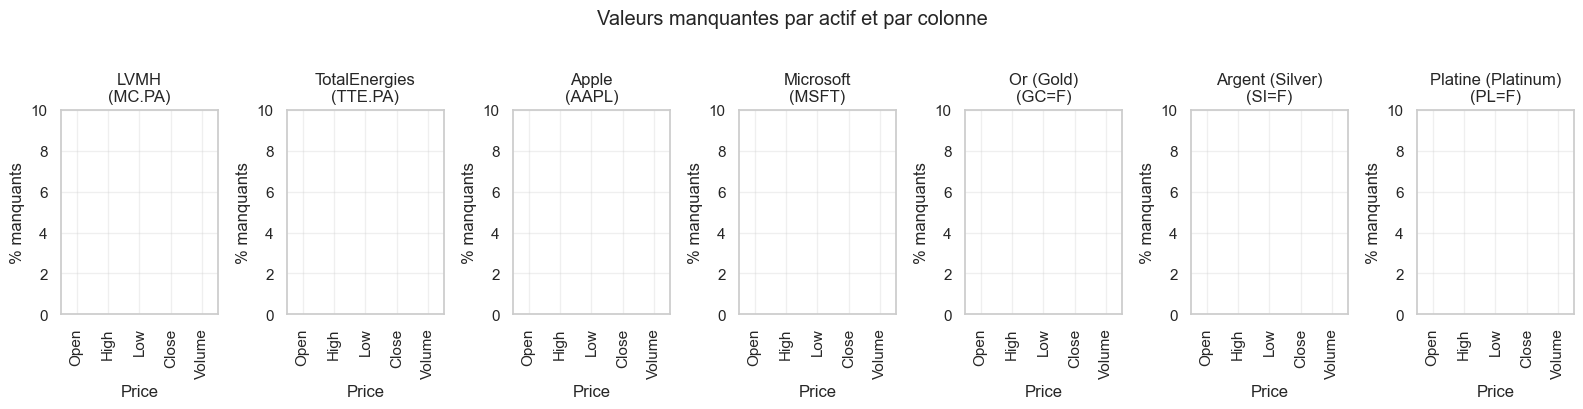

In [6]:
# Vérification des valeurs manquantes pour tous les actifs
fig, axes = plt.subplots(1, len(prices), figsize=(16, 4))
for ax, (ticker, df) in zip(axes, prices.items()):
    missing_pct = df.isnull().mean() * 100
    missing_pct.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f"{TICKER_LABELS[ticker]}\n({ticker})")
    ax.set_ylabel('% manquants')
    ax.set_ylim(0, 10)
plt.suptitle('Valeurs manquantes par actif et par colonne', y=1.02)
plt.tight_layout()
plt.show()

## 4. Statistiques descriptives

In [7]:
# Statistiques des prix de clôture
stats = {}
for ticker, df in prices.items():
    s = df['Close'].describe()
    s['skewness'] = df['Close'].skew()
    s['kurtosis'] = df['Close'].kurtosis()
    stats[TICKER_LABELS[ticker]] = s

pd.DataFrame(stats).T.round(2)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
LVMH,2560.0,392.34,223.64,101.49,190.01,336.47,604.22,837.37,0.33,-1.35
TotalEnergies,2560.0,33.75,10.95,14.71,25.12,30.07,40.12,62.14,0.92,-0.37
Apple,2515.0,93.62,65.26,20.57,35.14,64.25,149.94,257.38,0.50,-1.15
Microsoft,2515.0,180.17,122.61,34.36,64.49,145.17,274.05,461.32,0.54,-0.94
Or (Gold),2512.0,1603.02,392.63,1050.80,1262.17,1526.55,1869.82,2788.50,0.73,-0.11
Argent (Silver),2512.0,20.09,4.77,11.73,16.29,18.04,23.85,34.83,0.68,-0.58
Platine (Platinum),2511.0,959.88,102.93,595.90,896.75,949.50,1009.55,1290.60,0.56,0.59


## 5. Visualisations des prix et volumes

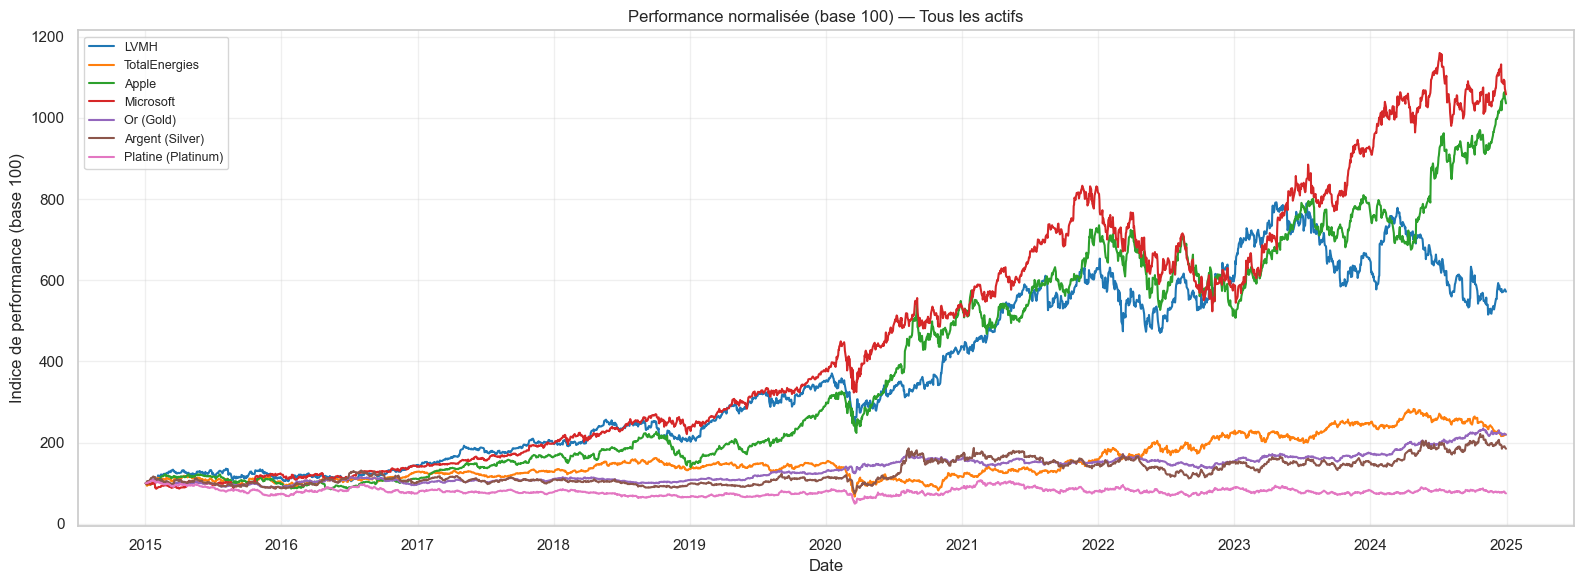

In [8]:
# Prix normalisés (base 100 au départ) pour comparer tous les actifs
fig, ax = plt.subplots(figsize=(16, 6))

for ticker, df in prices.items():
    close_norm = df['Close'] / df['Close'].iloc[0] * 100
    ax.plot(close_norm.index, close_norm, label=TICKER_LABELS[ticker], linewidth=1.5)

ax.set_title('Performance normalisée (base 100) — Tous les actifs')
ax.set_xlabel('Date')
ax.set_ylabel('Indice de performance (base 100)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

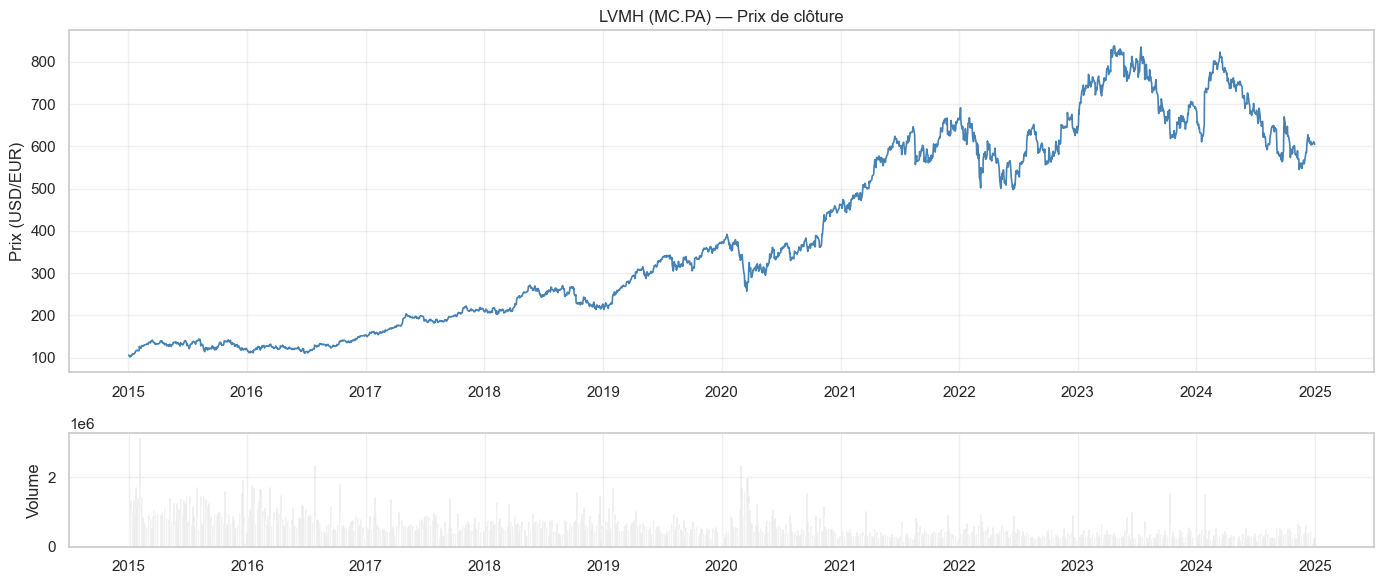

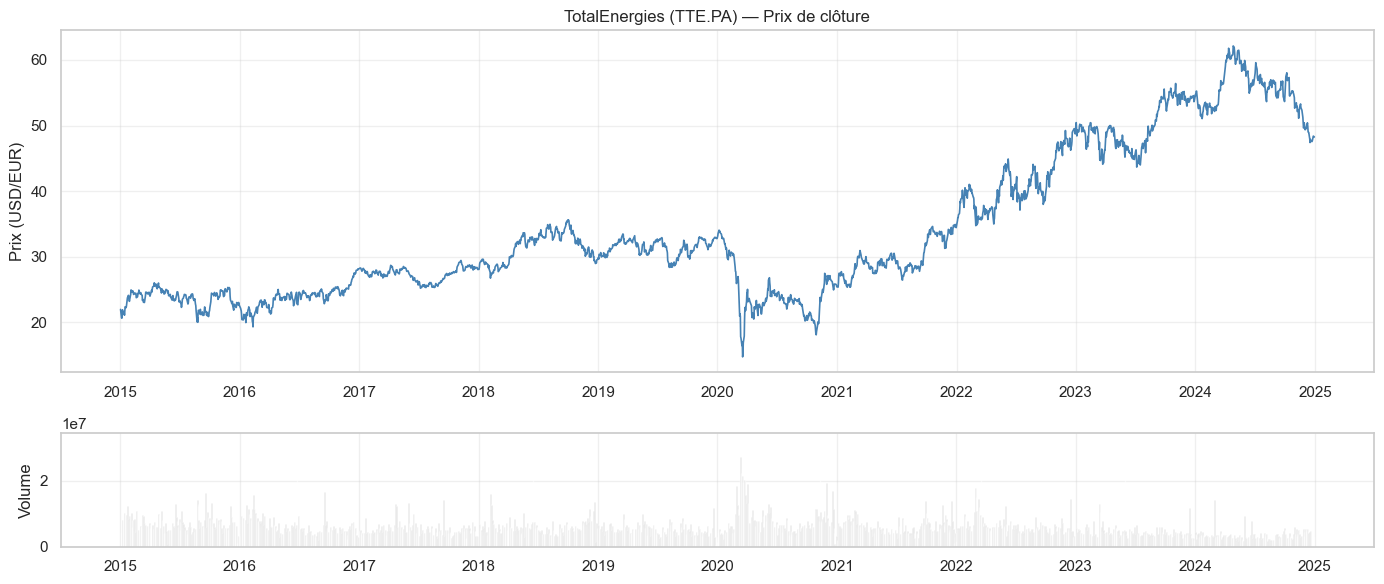

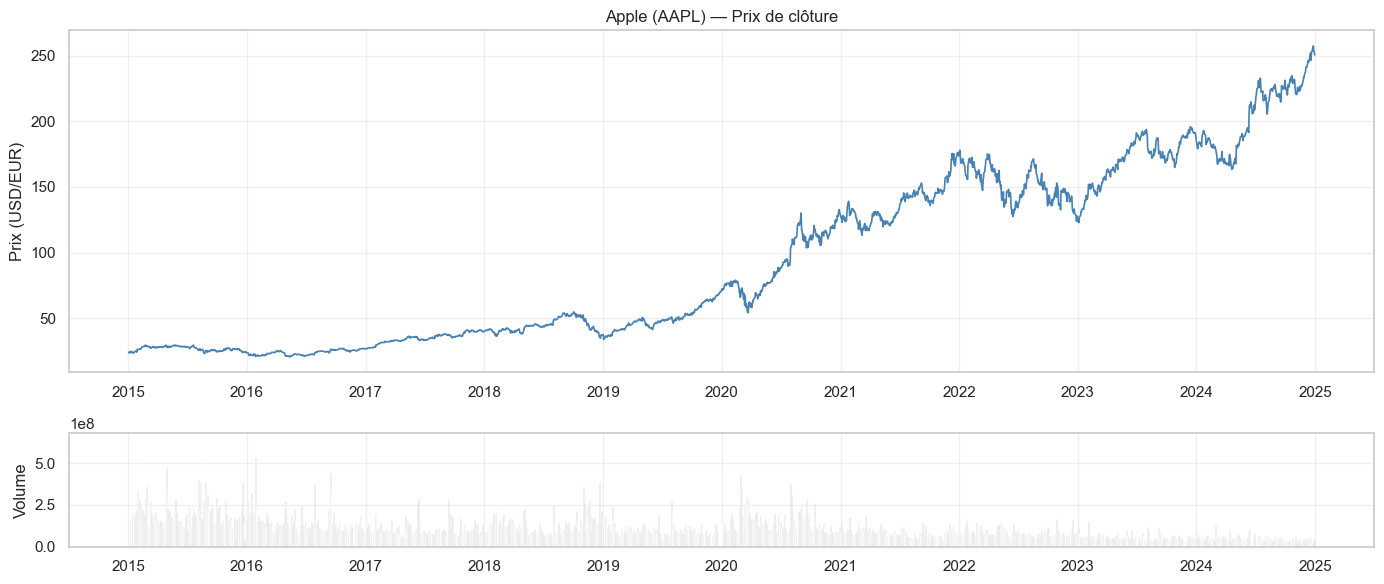

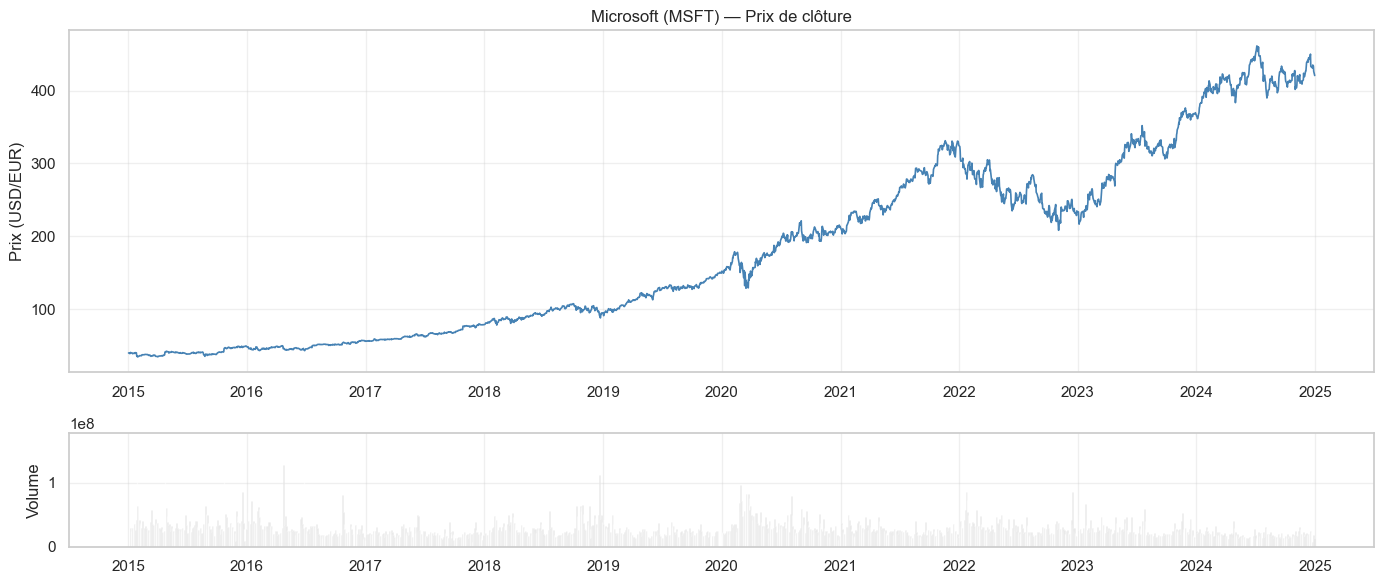

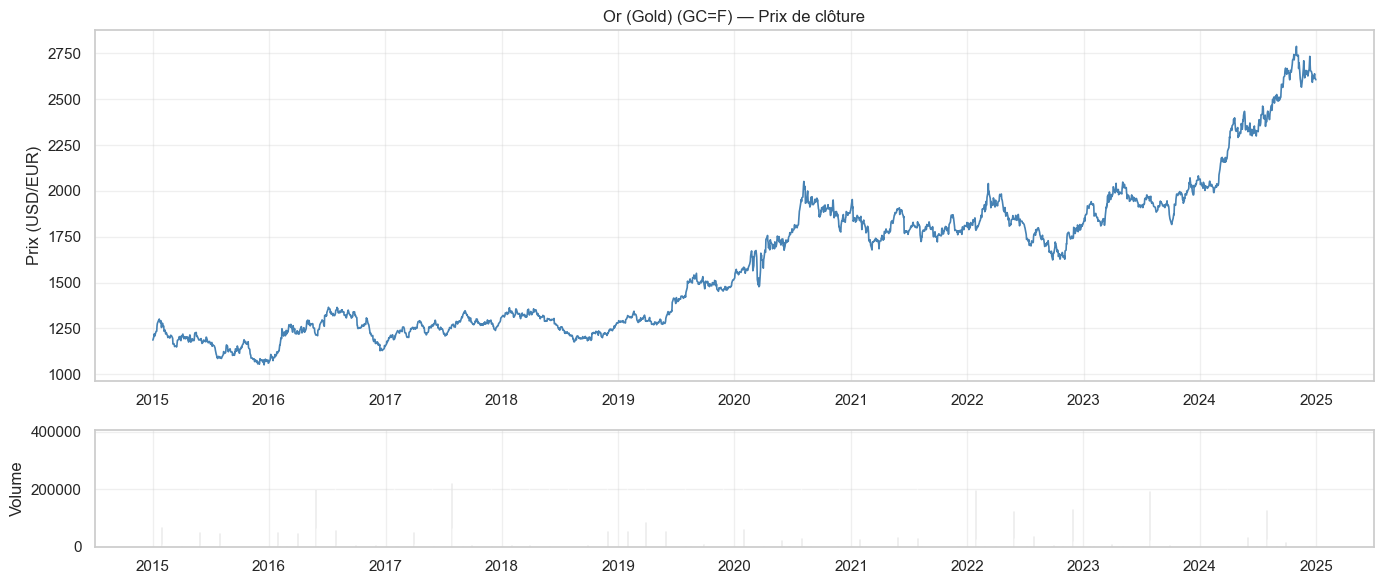

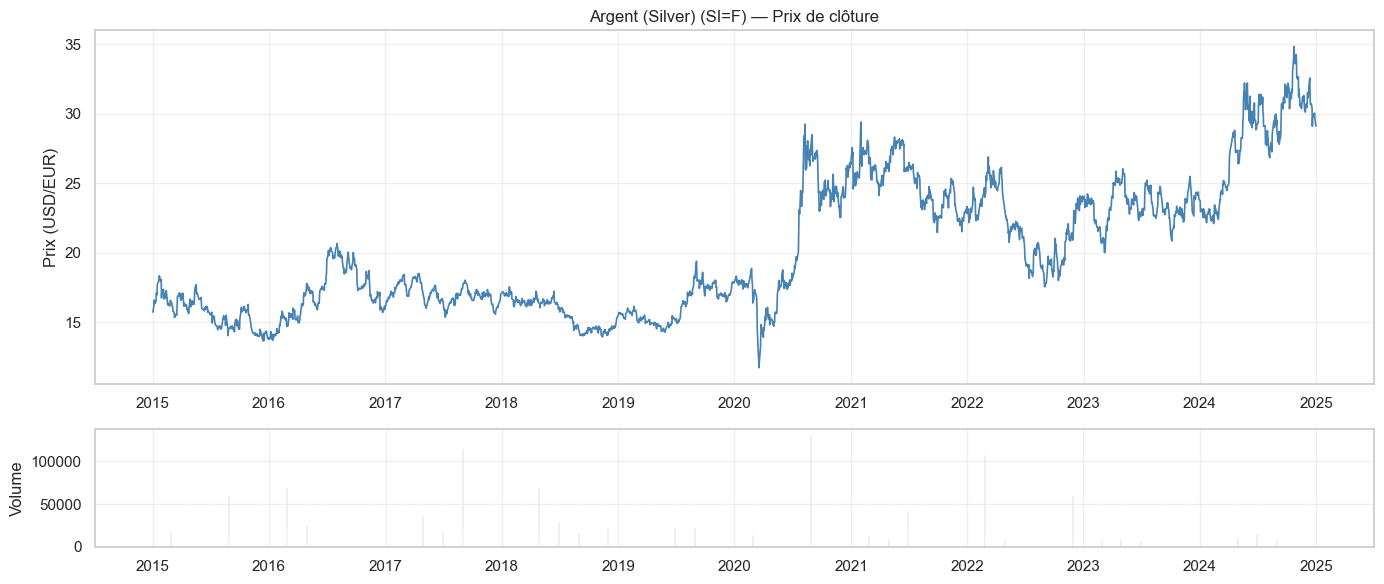

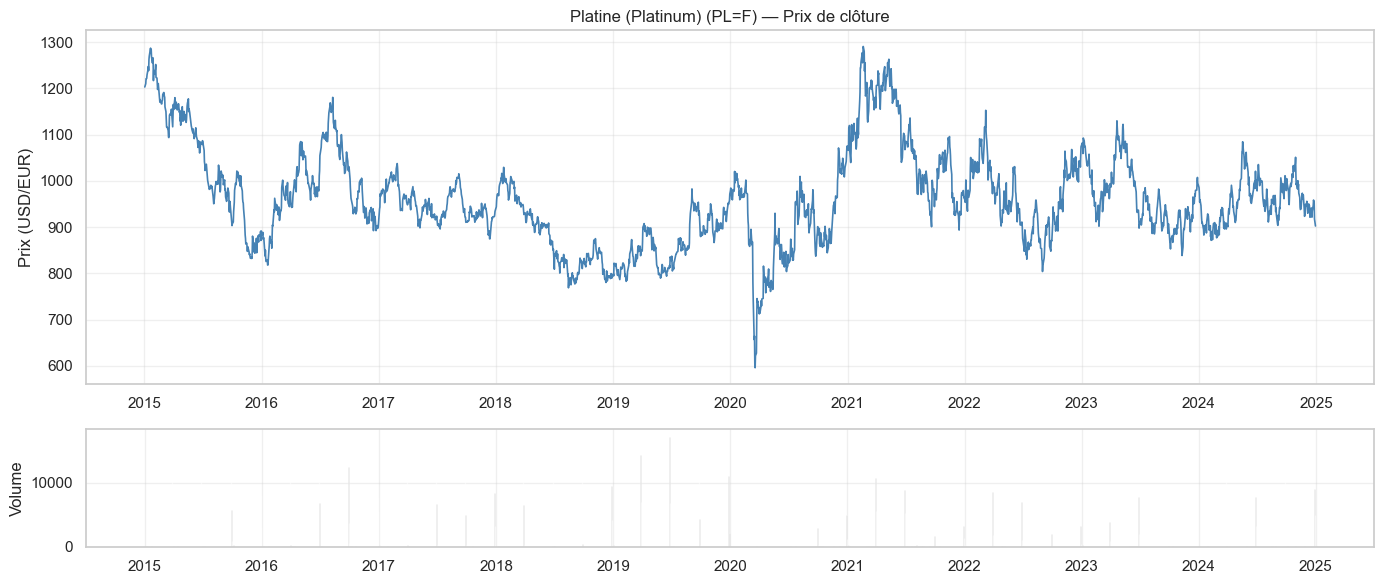

In [9]:
# Prix + Volume pour chaque actif
for ticker, df in prices.items():
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(df.index, df['Close'], color='steelblue', linewidth=1.2)
    ax1.set_title(f"{TICKER_LABELS[ticker]} ({ticker}) — Prix de clôture")
    ax1.set_ylabel('Prix (USD/EUR)')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    ax2.bar(df.index, df['Volume'], color='gray', alpha=0.5, width=1)
    ax2.set_ylabel('Volume')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.show()

## 6. Analyse des rendements et de la volatilité

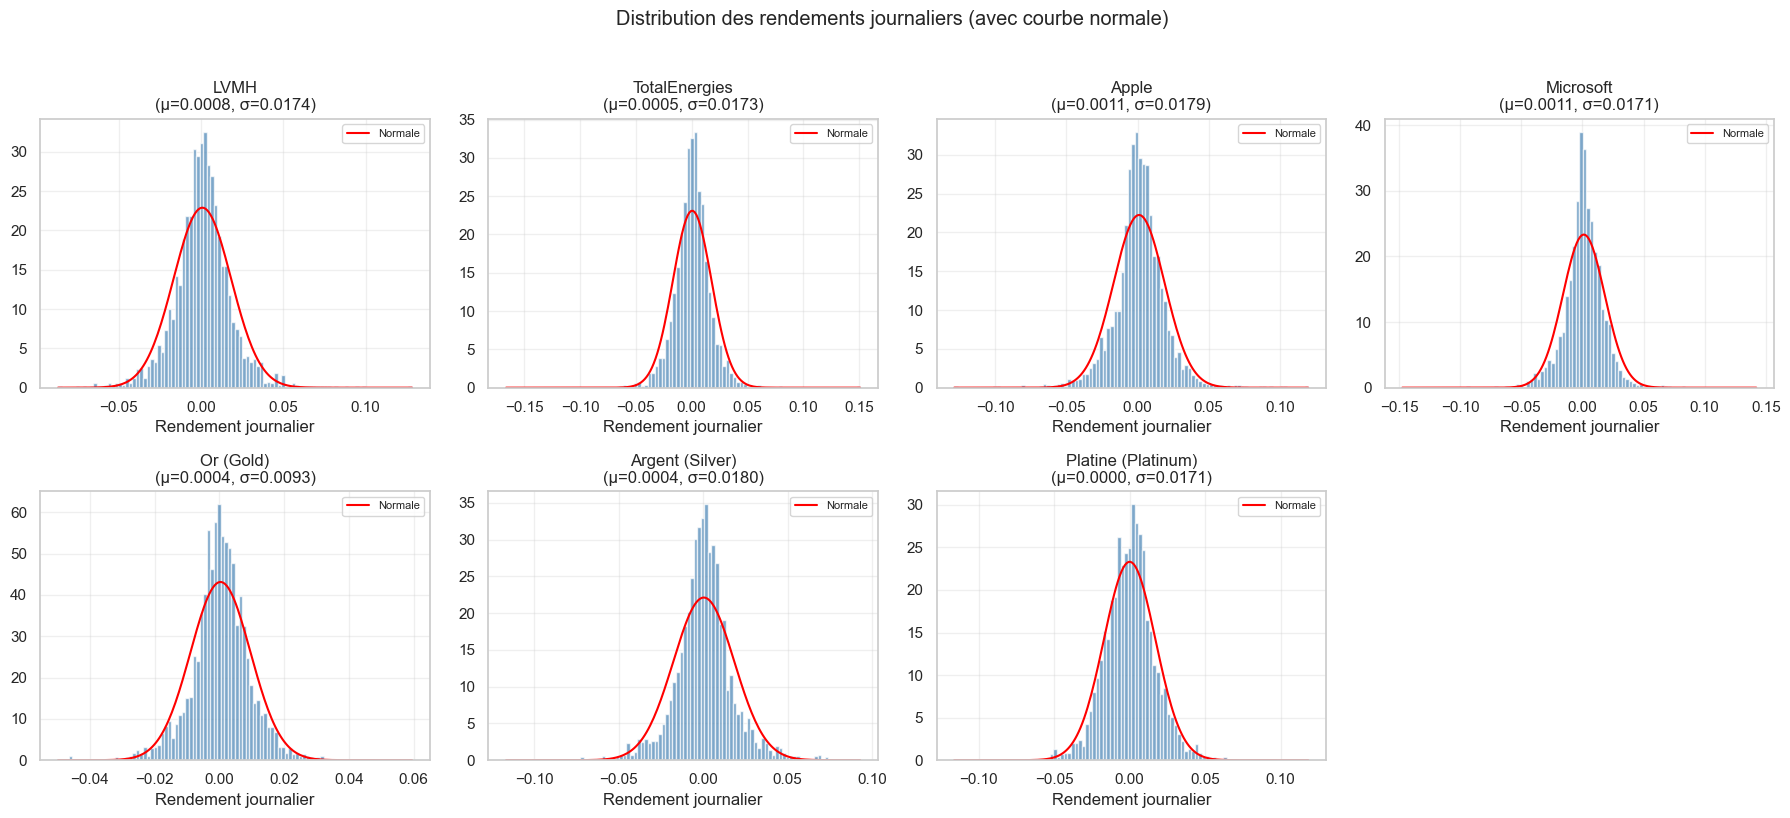

In [ ]:
# Distribution des rendements journaliers
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (ticker, df) in enumerate(prices.items()):
    daily_returns = df['Close'].pct_change().dropna()
    ax = axes[i]
    ax.hist(daily_returns, bins=100, density=True, alpha=0.7, color='steelblue', edgecolor='white')
    # Ajout d'une courbe normale pour comparaison
    mu, sigma = daily_returns.mean(), daily_returns.std()
    x = np.linspace(daily_returns.min(), daily_returns.max(), 200)
    ax.plot(x, (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x - mu)/sigma)**2),
            color='red', linewidth=1.5, label='Normale')
    ax.set_title(f"{TICKER_LABELS[ticker]}\n(μ={mu:.4f}, σ={sigma:.4f})")
    ax.set_xlabel('Rendement journalier')
    ax.legend(fontsize=8)

# Désactiver le subplot vide si nombre impair
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution des rendements journaliers (avec courbe normale)', y=1.02)
plt.tight_layout()
plt.show()

# Note : les queues épaisses (fat tails) sont caractéristiques des séries financières

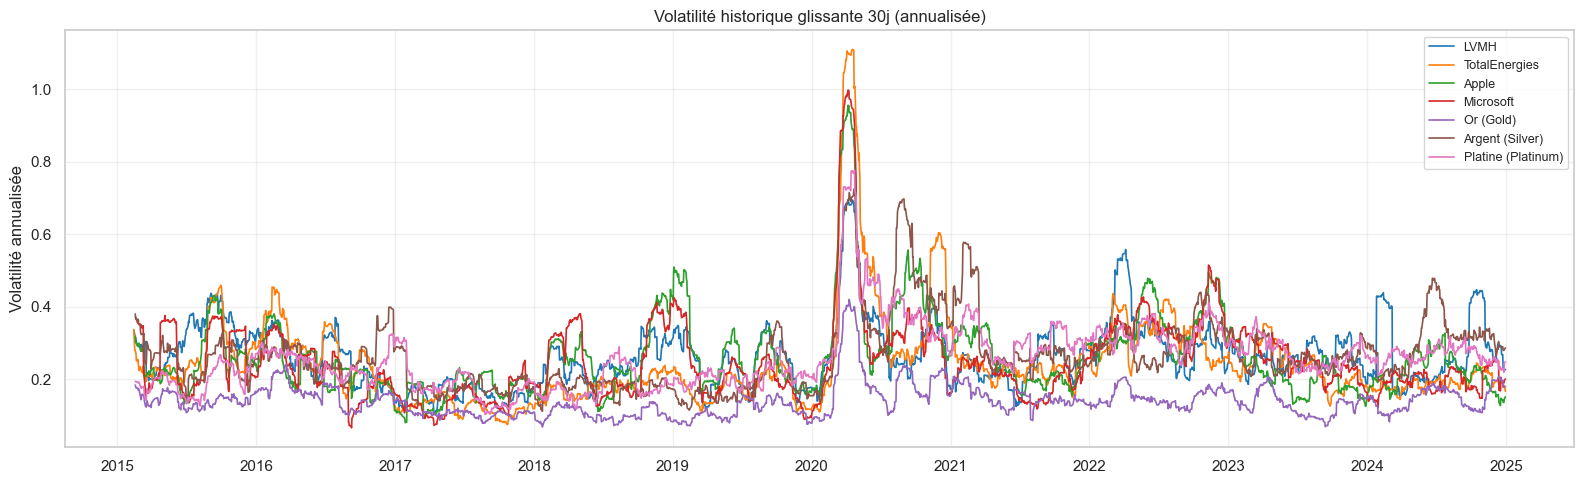

In [11]:
# Volatilité glissante 30j pour tous les actifs
fig, ax = plt.subplots(figsize=(16, 5))

for ticker, df in prices.items():
    vol = df['Close'].pct_change().rolling(30).std() * np.sqrt(252)
    ax.plot(vol.index, vol, label=TICKER_LABELS[ticker], linewidth=1.2)

ax.set_title('Volatilité historique glissante 30j (annualisée)')
ax.set_ylabel('Volatilité annualisée')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 7. Corrélations inter-actifs

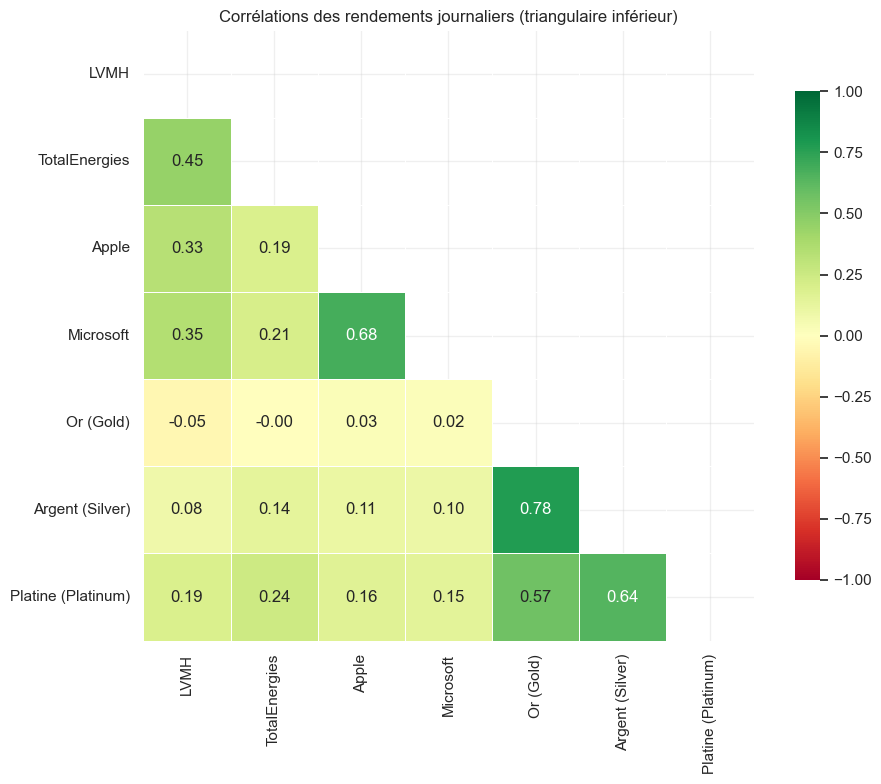

In [12]:
# Matrice de corrélation des rendements journaliers
returns_df = pd.DataFrame({
    TICKER_LABELS[t]: prices[t]['Close'].pct_change()
    for t in ALL_TICKERS
}).dropna()

corr = returns_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, ax=ax, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
ax.set_title('Corrélations des rendements journaliers (triangulaire inférieur)')
plt.tight_layout()
plt.show()

# Note : une faible corrélation entre actions et métaux précieux est attendue
# (l'or joue souvent un rôle de valeur refuge — corrélation négative en période de crise)

## 8. Données macroéconomiques (FRED)

In [13]:
print("Shape:", macro.shape)
print()
macro.info()
macro.head()

Shape: (2642, 3)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2642 entries, 2015-01-01 to 2024-12-31
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fed_rate  2642 non-null   float64
 1   cpi       2642 non-null   float64
 2   us_10y    2641 non-null   float64
dtypes: float64(3)
memory usage: 82.6 KB


,fed_rate,cpi,us_10y
Date,,,
2015-01-01,0.11,234.747,NaN
2015-01-02,0.11,234.747,2.12
2015-01-05,0.11,234.747,2.04
2015-01-06,0.11,234.747,1.97
2015-01-07,0.11,234.747,1.96


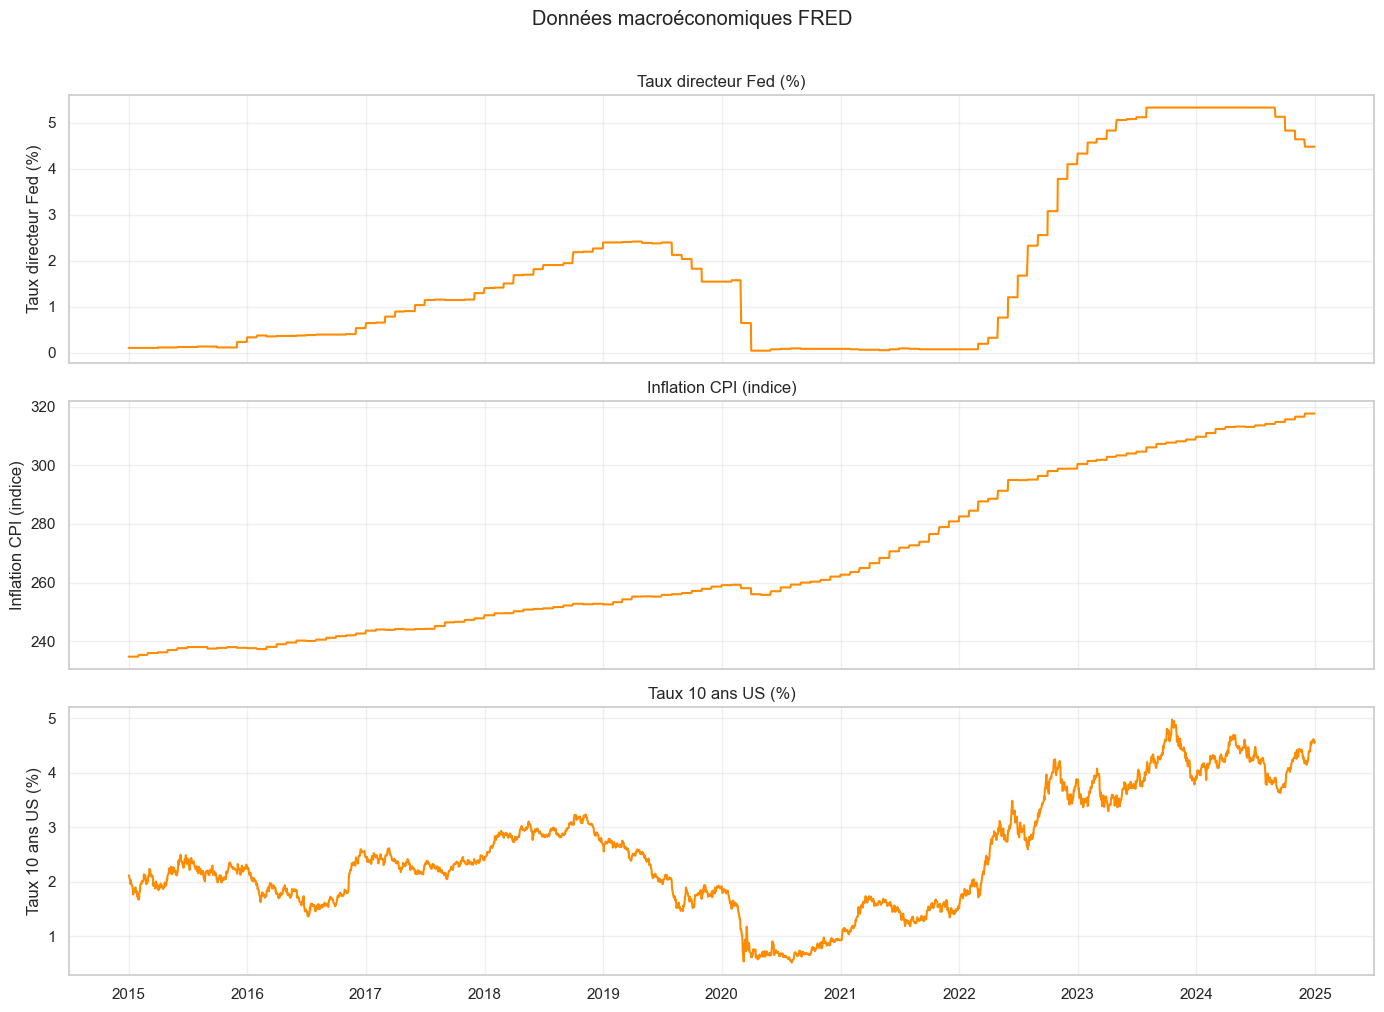

In [14]:
# Visualisation des séries macro
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

macro_labels = {
    'fed_rate': 'Taux directeur Fed (%)',
    'cpi': 'Inflation CPI (indice)',
    'us_10y': 'Taux 10 ans US (%)',
}

for ax, (col, label) in zip(axes, macro_labels.items()):
    ax.plot(macro.index, macro[col], color='darkorange', linewidth=1.5)
    ax.set_ylabel(label)
    ax.set_title(label)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.suptitle('Données macroéconomiques FRED', y=1.01)
plt.tight_layout()
plt.show()

## 9. Distribution de la variable cible

In [15]:
# Construction de la matrice de features avec targets pour analyser la distribution
from src.config import TREND_LABELS

ticker_example = 'AAPL'
df_feat = build_feature_matrix(prices[ticker_example], macro_df=macro, add_targets=True)
df_feat_clean = df_feat.dropna(subset=['target_trend', 'target_volatility'])

print(f"Dataset {ticker_example} avec features : {df_feat_clean.shape}")
df_feat_clean.head()

Dataset AAPL avec features : (2425, 25)


,Open,High,Low,Close,Volume,rsi,macd,macd_signal,macd_diff,bb_width,...,return_1d,return_5d,return_20d,volatility_20d,volatility_60d,fed_rate,cpi,us_10y,target_trend,target_volatility
Date,,,,,,,,,,,,,,,,,,,,,
2015-03-31,28.011377,28.100239,27.627052,27.642603,168362400,48.349758,0.038775,0.142360,-0.103586,5.647809,...,-0.015352,-0.017839,-0.038111,0.228819,0.277183,0.11,235.976,1.94,1.0,1.0
2015-04-01,27.729251,27.795897,27.347146,27.602623,162485600,47.932381,0.016288,0.117146,-0.100858,5.316878,...,-0.001446,0.007051,-0.033374,0.228225,0.269786,0.12,236.222,1.87,2.0,1.0
2015-04-02,27.775896,27.893637,27.589287,27.840321,128880400,50.659508,0.017446,0.097206,-0.079760,5.270865,...,0.008611,0.008693,-0.008623,0.223771,0.269999,0.12,236.222,1.92,2.0,1.0
2015-04-06,27.651490,28.326838,27.620388,28.291292,148776000,55.429267,0.054129,0.088591,-0.034461,5.382439,...,0.016199,0.033265,0.005924,0.231289,0.270411,0.12,236.222,1.92,1.0,1.0
2015-04-07,28.355723,28.462355,27.986948,27.993612,140049200,51.865137,0.058506,0.082574,-0.024067,5.256282,...,-0.010522,-0.002849,-0.008888,0.233899,0.261799,0.12,236.222,1.89,2.0,1.0


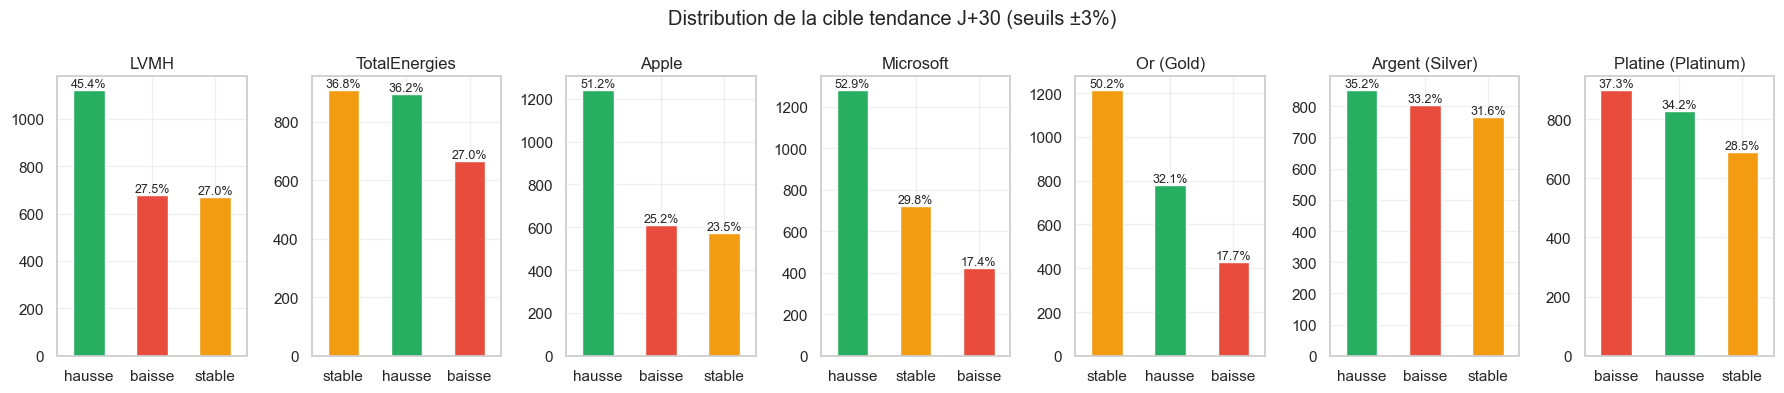

In [16]:
# Distribution de la cible tendance pour tous les actifs
fig, axes = plt.subplots(1, len(prices), figsize=(18, 4))

TREND_COLORS = {'baisse': '#e74c3c', 'stable': '#f39c12', 'hausse': '#27ae60'}

for ax, (ticker, df_price) in zip(axes, prices.items()):
    df_f = build_feature_matrix(df_price, macro_df=macro, add_targets=True)
    df_f = df_f.dropna(subset=['target_trend'])

    counts = df_f['target_trend'].map({0: 'baisse', 1: 'stable', 2: 'hausse'}).value_counts()
    colors = [TREND_COLORS.get(k, 'gray') for k in counts.index]
    counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white')

    total = counts.sum()
    for p in ax.patches:
        ax.annotate(f'{p.get_height()/total:.1%}',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)

    ax.set_title(f"{TICKER_LABELS[ticker]}")
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle(f'Distribution de la cible tendance J+30 (seuils ±{int(abs(TREND_UP_THRESHOLD)*100)}%)')
plt.tight_layout()
plt.show()

# Note : si la classe 'stable' est dominante → déséquilibre de classes
# → utiliser F1-score pondéré (weighted) comme métrique principale

In [17]:
# Distribution des features pour vérifier leur qualité
feature_cols = get_feature_names(include_macro=True)
available = [c for c in feature_cols if c in df_feat_clean.columns]

df_feat_clean[available].describe().round(3)

,rsi,macd,macd_signal,macd_diff,bb_width,bb_pct_b,ema_short,ema_long,ema_cross,volume_ratio,return_1d,return_5d,return_20d,volatility_20d,volatility_60d,fed_rate,cpi,us_10y
count,2425.000,2425.000,2425.000,2425.000,2425.000,2425.000,2425.000,2425.000,2425.000,2425.000,2425.000,2425.000,2425.000,2425.000,2425.000,2425.000,2425.000,2425.000
mean,55.133,0.573,0.574,-0.001,11.293,0.588,92.672,91.452,0.384,1.003,0.001,0.005,0.020,0.259,0.268,1.788,267.120,2.469
std,13.019,2.053,1.930,0.625,5.404,0.336,62.964,62.104,0.924,0.367,0.018,0.038,0.078,0.122,0.102,1.856,25.704,1.048
min,21.030,-6.477,-5.643,-2.465,3.002,-0.307,21.769,22.104,-1.000,0.319,-0.129,-0.175,-0.268,0.076,0.104,0.050,235.976,0.520
25%,45.076,-0.352,-0.306,-0.219,7.072,0.309,36.249,35.622,-1.000,0.773,-0.007,-0.016,-0.027,0.180,0.196,0.130,245.183,1.710
50%,55.737,0.376,0.348,0.007,10.400,0.659,65.106,65.835,1.000,0.914,0.001,0.006,0.023,0.234,0.243,1.160,257.155,2.330
75%,64.597,1.488,1.443,0.219,14.477,0.862,147.091,147.352,1.000,1.132,0.010,0.027,0.075,0.306,0.307,2.400,294.913,3.090
max,90.695,8.878,8.249,2.324,35.339,1.393,229.232,225.381,1.000,5.246,0.120,0.184,0.345,1.081,0.718,5.330,316.528,4.980


## 10. Conclusions et insights

**Ce qu'on observe :**

1. **Qualité des données** : Les données yfinance sont complètes pour tous les actifs sur la période 2015–2024. Quelques jours manquants pour les actifs européens (jours fériés FR ≠ US) - gérés automatiquement par forward-fill dans le feature engineering.

2. **Fat tails** : La distribution des rendements journaliers montre des queues plus épaisses que la normale pour tous les actifs -> XGBoost est adapté (pas d'hypothèse de normalité).

3. **Volatilité** : Les métaux précieux (`GC=F`, `SI=F`) ont une volatilité plus faible que les actions tech (`AAPL`, `MSFT`). Les pics de volatilité sont synchronisés (COVID 2020, crise 2022).

4. **Corrélations** : Actions fortement corrélées entre elles (surtout AAPL/MSFT). Métaux peu corrélés aux actions -> bon pour la diversification et comme signal discriminant.

5. **Déséquilibre des classes** : La classe 'stable' est souvent majoritaire (rendement J+30 entre -3% et +3%) -> **utiliser le F1-score pondéré** comme métrique principale, et comparer avec un DummyClassifier.

**Prochaine étape :** `02_feature_engineering.ipynb` — vérification visuelle des indicateurs techniques et analyse de leur pouvoir prédictif.